In [2]:
import tensorflow as tf

In [3]:
#other imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Get the data
import urllib.request
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv',
    'moore.csv'
)

('moore.csv', <http.client.HTTPMessage at 0x1787f368a50>)

In [5]:
with open('moore.csv') as f:
    for _ in range(10):
        print(f.readline(), end='')

1971,2300
1972,3500
1973,2500
1973,2500
1974,4100
1974,4500
1974,8000
1975,3510
1976,5000
1976,8500


In [6]:
#load in the data
data = pd.read_csv('moore.csv', header=None).to_numpy()

In [7]:
data

array([[       1971,        2300],
       [       1972,        3500],
       [       1973,        2500],
       [       1973,        2500],
       [       1974,        4100],
       [       1974,        4500],
       [       1974,        8000],
       [       1975,        3510],
       [       1976,        5000],
       [       1976,        8500],
       [       1976,        6500],
       [       1978,        9000],
       [       1978,       29000],
       [       1979,       17500],
       [       1979,       29000],
       [       1979,       68000],
       [       1981,       11500],
       [       1982,       55000],
       [       1982,      134000],
       [       1983,       22000],
       [       1984,       63000],
       [       1984,      190000],
       [       1985,      275000],
       [       1985,       25000],
       [       1985,       16000],
       [       1986,      110000],
       [       1986,      375000],
       [       1986,       30000],
       [       1987,

In [8]:
X = data[:,0].reshape(-1, 1)  #this means that we fill all the rows and only one column, making an N X D
Y = data[:,1]

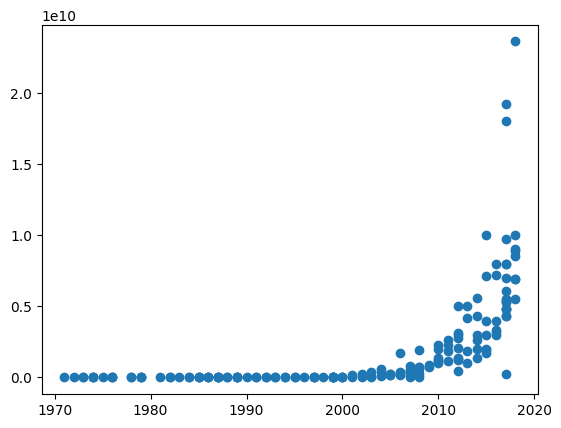

In [9]:
plt.scatter(X, Y)

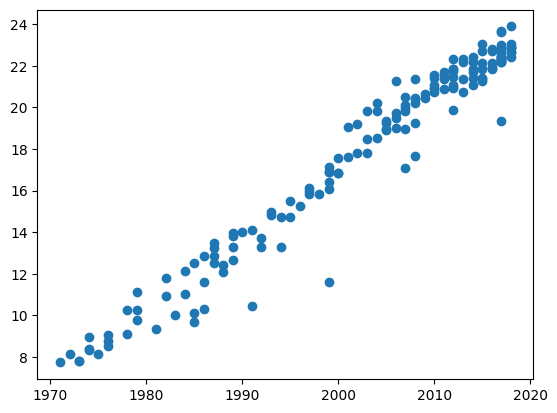

In [10]:
Y = np.log(Y)
plt.scatter(X, Y)

In [11]:
X = X - X.mean()

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1),
    ])

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(0.001, 0.9), 
    loss='mse',
)

In [14]:
def schedule(epoch, lr):
    if epoch >= 50:
        return 0.0001
    return 0.001

scheduler = tf.keras.callbacks.LearningRateScheduler(schedule)

In [15]:
r = model.fit(X, Y, epochs=100, callbacks=[scheduler])

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 559.1349 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 466.3440 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 342.2927 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 345.9656 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 422.3350 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 201.0356 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 123.7188 - learning_rate: 0.0010
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92.5548 - learning_rate: 0.0010
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 61.3869 - learning_rate: 0.0010
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 41.5646 - learning_rate: 0.0010
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.3945 - learning_rate: 0.0010
Epoch 12/100

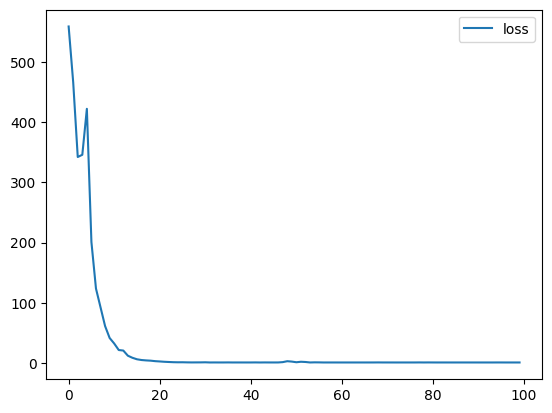

In [16]:
#plot the loss
plt.plot(r.history['loss'], label='loss')
plt.legend()

In [17]:
model.layers

[<Dense name=dense, built=True>]

In [18]:
model.layers[0].get_weights()

[array([[0.34384847]], dtype=float32), array([17.727285], dtype=float32)]

In [19]:
a = model.layers[0].get_weights()[0][0,0]
a

0.34384847

In [20]:
X = X.flatten()
denominator = X.dot(X) - X.mean() * X.sum()
a = ( X.dot(Y) - Y.mean() * X.sum() ) / denominator
b = ( Y.mean() * X.dot(X) - X.mean() * X.dot(Y) ) / denominator
print(a, b)

0.341682487387313 17.764939393631764


In [21]:
print("Time to double:", np.log(2) / a)

Time to double: 2.0286295205239204


<div style="text-align:center">
    <h1>
        Part 2: Making predictions
    </h1>
</div>



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


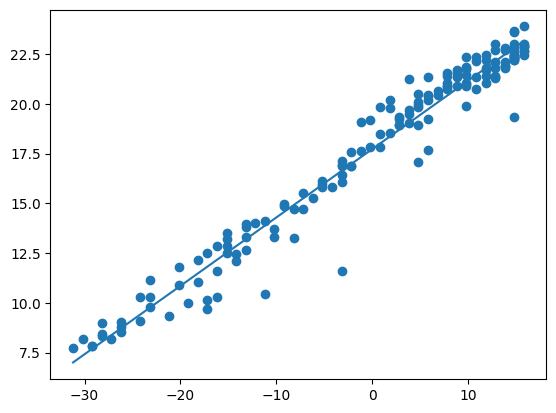

In [22]:
Yhat = model.predict(X).flatten()
plt.scatter(X, Y)
plt.plot(X, Yhat)

In [24]:
w, b = model.layers[0].get_weights()

In [23]:
X = X.reshape(-1, 1)

In [25]:
Yhat2 = (X.dot(w) + b).flatten()

In [26]:
np.allclose(Yhat, Yhat2)

True

<div style="text-align:center">
    <h1>
        Part 3: Saving and Loading a model
    </h1>
</div>



In [27]:
model.save('linearregression.h5')